In [1]:
!pip install -qU bitsandbytes accelerate datasets transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 32.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 115.5 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 625.2/625.2 kB 43.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 102.5 MB/s eta 0:00:0000:01


In [2]:
# Installations and Authentication
!pip install -qU vllm crewai langchain_openai transformers sentencepiece accelerate huggingface_hub
!pip install -q datasets==2.20.0 

from kaggle_secrets import UserSecretsClient
from huggingface_hub import login

# Authenticate with Hugging Face using your Kaggle Secret
user_secrets = UserSecretsClient()
hf_token = user_secrets.get_secret("HF_TOKEN")
login(token=hf_token)

print("Environment Ready & Hugging Face Authenticated!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.3/89.3 kB 5.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.4/80.4 kB 7.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.9/87.9 kB 6.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.1/68.1 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 433.2/433.2 MB 4.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.6/192.6 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 101.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.0/111.0 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━

In [3]:
# Generate Baseline Summaries
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from datasets import load_dataset
from tqdm.auto import tqdm  # <-- Added for the progress bar
import torch
import pandas as pd

print("Downloading XL-Sum Bengali Test Dataset...")
dataset = load_dataset("csebuetnlp/xlsum", "bengali", split="test", trust_remote_code=True)

# 1. CHANGE MADE HERE: Now selecting exactly 200 samples for your benchmark!
print("Slicing 200 samples for the benchmark...")
test_data = dataset.select(range(200)) 

print("Downloading mT5 Model...")
model_name = "csebuetnlp/mT5_multilingual_XLSum"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to("cuda:0")

generated_data = []

print("Generating Summaries (This will take a few minutes)...")
# 2. CHANGE MADE HERE: Wrapped test_data in tqdm for a progress bar
for item in tqdm(test_data, total=len(test_data), desc="Generating"):
    article = item['text']
    
    # Tokenize and generate
    input_ids = tokenizer(article, return_tensors="pt", max_length=512, truncation=True)["input_ids"].to("cuda:0")
    output_ids = model.generate(input_ids, max_length=64, num_beams=4, length_penalty=0.6)
    summary = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    
    generated_data.append({
        "id": item['id'],
        "article": article,
        "human_summary": item['summary'],
        "mt5_summary": summary
    })

df_baseline = pd.DataFrame(generated_data)

# Clean up memory so the GPUs are fresh for the evaluation ensemble later
import gc
del model 
del tokenizer
gc.collect()
torch.cuda.empty_cache() 

print("✅ Success! 200 mT5 Summaries Generated and saved to memory.")

Generating train split:   0%|          | 0/8102 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1012 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1012 [00:00<?, ? examples/s]

Slicing 200 samples for the benchmark...


tokenizer_config.json:   0%|          | 0.00/375 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/2.33G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.33G [00:00<?, ?B/s]

Generating Summaries (This will take a few minutes)...


Generating:   0%|          | 0/200 [00:00<?, ?it/s]

✅ Success! 200 mT5 Summaries Generated and saved to memory.


In [4]:
import gc, json, torch, re, os
import pandas as pd
from tqdm.auto import tqdm # <-- IMPORT TQDM FOR PROGRESS BARS
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

# 1. RUN ON THE FULL 200 SAMPLES
print("Loading all 200 samples...")
df_full_batch = df_baseline # <-- Using the full dataset now!

JUDGE_MODELS = [
    "NousResearch/Meta-Llama-3-8B-Instruct", 
    "google/gemma-2-9b-it",
    "Qwen/Qwen2.5-7B-Instruct"
]

ensemble_results = {
    row['id']: {'mt5_summary': row['mt5_summary'], 'votes': [], 'explanations': [], 'error_categories': []} 
    for _, row in df_full_batch.iterrows()
}

bnb_config = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16)

def get_relevant_context(article, summary, top_n=8):
    sentences = article.split('।')
    summary_words = set(summary.split())
    scored_sentences = []
    for sentence in sentences:
        sent_words = set(sentence.split())
        score = len(summary_words.intersection(sent_words))
        scored_sentences.append((score, sentence))
    scored_sentences.sort(reverse=True, key=lambda x: x[0])
    best_sentences = [s[1] for s in scored_sentences[:top_n]]
    return " । ".join(best_sentences) + " ।"


# 2. THE EVALUATION LOOP (With Auto-Save and Progress Bars)
for model_id in JUDGE_MODELS:
    print(f"\n" + "="*50)
    print(f" LOADING JUDGE: {model_id}")
    print("="*50)
    
    tokenizer = AutoTokenizer.from_pretrained(model_id)
    model = AutoModelForCausalLM.from_pretrained(model_id, quantization_config=bnb_config, device_map="auto")
    
    def ask_judge(system_prompt, user_prompt):
        # Gemma models do not support the "system" role, so we merge it
        if "gemma" in model_id.lower():
            combined_prompt = f"{system_prompt}\n\n{user_prompt}"
            messages = [{"role": "user", "content": combined_prompt}]
        else:
            messages = [
                {"role": "system", "content": system_prompt}, 
                {"role": "user", "content": user_prompt}
            ]
            
        prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=2048).to("cuda:0")
        
        with torch.inference_mode():
            outputs = model.generate(
                **inputs, 
                max_new_tokens=512, 
                do_sample=False, 
                pad_token_id=tokenizer.eos_token_id
            )
        text = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
        return text.strip()

    # Wrap df.iterrows() in tqdm for a progress bar!
    print(f"Starting 200-sample audit with {model_id.split('/')[-1]}...")
    for index, row in tqdm(df_full_batch.iterrows(), total=len(df_full_batch), desc=f"Auditing"):
        article_id = row['id']
        safe_article = get_relevant_context(row['article'], row['mt5_summary'])
        
        sys_1 = "You are a data extractor. Extract the main claims from the Bengali summary. Output ONLY a numbered list of claims translated to English. Do not write any introductory text."
        facts = ask_judge(sys_1, f"Summary:\n{row['mt5_summary']}")
        
        sys_2 = """You are a strict text-matching bot. Your ONLY job is to check if the English claims are present in the Bengali text. RULES: 1. DO NOT use outside knowledge. 2. If the claim is missing or contradicts the text, it is 'Not Supported'. Format: Claim: [claim] \n Status: [Supported / Not Supported] \n Reason: [One short sentence]"""
        report = ask_judge(sys_2, f"Bengali Article:\n{safe_article}\n\nClaims to verify:\n{facts}")
        sanitized_report = re.sub(r'[^\x00-\x7F]+', ' ', report)
        
        sys_3 = """You are a JSON formatter. Read the verification report. If ALL claims are 'Supported', output is_faithful: true and error_category: "None". If ANY claim is 'Not Supported', output is_faithful: false and categorize the error as one of: ["Entity", "Date/Time", "Number", "Contradiction", "Missing Info", "Other"]. Output strictly valid JSON. Format: {"is_faithful": boolean, "error_category": "Category", "explanation": "Why"}"""
        raw_output = ask_judge(sys_3, f"Report to process:\n{sanitized_report}")
        
        try:
            match = re.search(r'\{.*\}', raw_output.replace('\n', ' '))
            if match:
                data = json.loads(match.group())
                vote = 1 if data.get('is_faithful') is True else 0
                ensemble_results[article_id]['votes'].append(vote)
                ensemble_results[article_id]['explanations'].append(data.get('explanation', ''))
                ensemble_results[article_id]['error_categories'].append(data.get('error_category', 'None'))
            else:
                ensemble_results[article_id]['votes'].append(0) 
                ensemble_results[article_id]['explanations'].append('JSON Parse Error')
                ensemble_results[article_id]['error_categories'].append('Parse Error')
        except:
            ensemble_results[article_id]['votes'].append(0)
            ensemble_results[article_id]['explanations'].append('Exception')
            ensemble_results[article_id]['error_categories'].append('Exception')
            
    print(f" Unloading {model_id} and clearing VRAM...")
    del model
    del tokenizer
    gc.collect()
    torch.cuda.empty_cache()
    
    # --- AUTO-SAVE CHECKPOINT ---
    # Saves progress after every model so you never lose data!
    with open('checkpoint_backup.json', 'w') as f:
        json.dump(ensemble_results, f)
    print(f" Progress safely checkpointed to disk!")

# 3. CALCULATE MAJORITY VOTE ---
final_results = []
for article_id, data in ensemble_results.items():
    total_votes_for_faithful = sum(data['votes'])
    
    if total_votes_for_faithful >= 2:
        final_verdict = True
        status = "Faithful"
        final_error_type = "None"
    else:
        final_verdict = False
        status = "Hallucinated"
        # Find the most common error category among the models that flagged it
        errors = [err for err in data['error_categories'] if err and err not in ["None", "Parse Error", "Exception"]]
        final_error_type = max(set(errors), key=errors.count) if errors else "Other"
        
    final_results.append({
        'article_id': article_id,
        'mt5_summary': data['mt5_summary'],
        'llama3_reason': data['explanations'][0] if len(data['explanations']) > 0 else "Error",
        'gemma2_reason': data['explanations'][1] if len(data['explanations']) > 1 else "Error",
        'qwen_reason': data['explanations'][2] if len(data['explanations']) > 2 else "Error",
        'llama3_error': data['error_categories'][0] if len(data['error_categories']) > 0 else "Error",
        'gemma2_error': data['error_categories'][1] if len(data['error_categories']) > 1 else "Error",
        'qwen_error': data['error_categories'][2] if len(data['error_categories']) > 2 else "Error",
        'final_error_type': final_error_type, # <-- THE OVERALL CONSENSUS ERROR TYPE
        'votes_faithful': total_votes_for_faithful,
        'final_verdict': final_verdict,
        'status': status,
        
    })

df_consensus = pd.DataFrame(final_results)
df_consensus.to_csv("full_200_consensus.csv", index=False)
print("\n=== 200-SAMPLE AUDIT COMPLETE ===")
print(df_consensus[['article_id','final_error_type', 'votes_faithful', 'final_verdict', 'status']])



Loading all 200 samples...

 LOADING JUDGE: NousResearch/Meta-Llama-3-8B-Instruct


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/73.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/654 [00:00<?, ?B/s]

...

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

Starting 200-sample audit with Qwen2.5-7B-Instruct...


Auditing:   0%|          | 0/200 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


 Unloading Qwen/Qwen2.5-7B-Instruct and clearing VRAM...
 Progress safely checkpointed to disk!

=== 200-SAMPLE AUDIT COMPLETE ===
        article_id final_error_type  votes_faithful  final_verdict  \
0    news-45155508             None               3           True   
1    news-39127107             None               3           True   
2    news-49141918             None               3           True   
3    news-52808250             None               3           True   
4    news-49047323           Entity               1          False   
..             ...              ...             ...            ...   
195  news-51494022             None               3           True   
196  news-46358471             None               2           True   
197  news-50804643     Missing Info               0          False   
198  news-47116189             None               3           True   
199  news-48989199           Entity               1          False   

           status  
0       

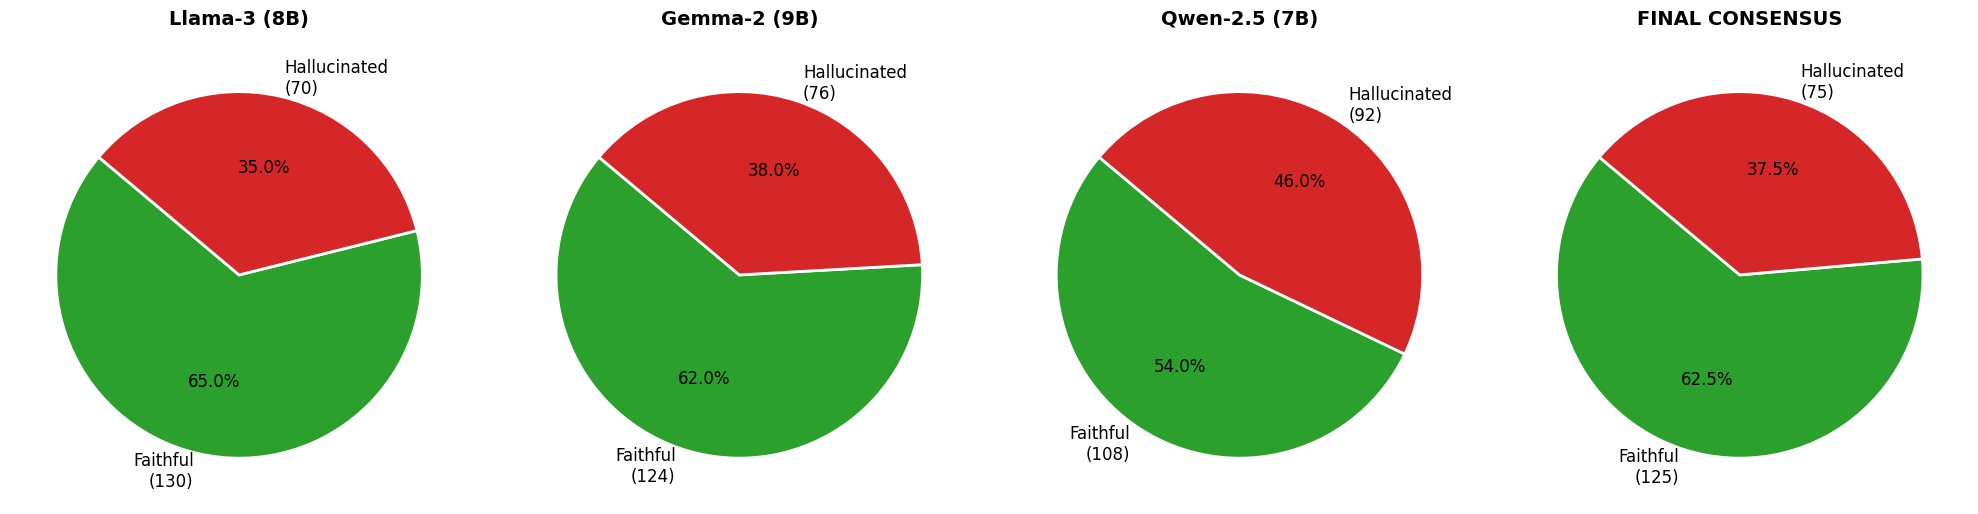

In [5]:
import matplotlib.pyplot as plt  # <-- THIS WAS THE MISSING IMPORT!

# 4. DRAW THE CHARTS
llama_votes = [data['votes'][0] for data in ensemble_results.values()]
gemma_votes = [data['votes'][1] for data in ensemble_results.values()]
qwen_votes = [data['votes'][2] for data in ensemble_results.values()]


consensus_faithful = df_consensus[df_consensus['status'] == 'Faithful'].shape[0]
consensus_hallucinated = df_consensus[df_consensus['status'] == 'Hallucinated'].shape[0]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
models = ["Llama-3 (8B)", "Gemma-2 (9B)", "Qwen-2.5 (7B)", "FINAL CONSENSUS"]
votes_list = [
    [sum(llama_votes), len(llama_votes) - sum(llama_votes)],
    [sum(gemma_votes), len(gemma_votes) - sum(gemma_votes)],
    [sum(qwen_votes), len(qwen_votes) - sum(qwen_votes)],
    [consensus_faithful, consensus_hallucinated]
]

colors = ['#2ca02c', '#d62728'] 

for ax, model_name, counts in zip(axes, models, votes_list):
    faithful_count, hallucinated_count = counts
    sizes = [faithful_count, hallucinated_count]
    ax.set_title(f"{model_name}", fontsize=14, fontweight='bold', pad=15)
    
    if sum(sizes) == 0:
        ax.text(0.5, 0.5, 'No Data', ha='center', va='center')
        ax.axis('off')
    else:
        labels = [f'Faithful\n({faithful_count})', f'Hallucinated\n({hallucinated_count})']
        ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors, 
               wedgeprops={'edgecolor': 'white', 'linewidth': 2}, textprops={'fontsize': 12})

plt.tight_layout()
plt.show()